In [1]:
import sys
import os

sys.path.append(os.path.abspath(".."))

In [2]:
import src.data_io as data
import src.visualization as viz
from src.config import load_config, update_config

In [3]:
config = load_config()

### How does AI usage evolve over time across different user groups?

In [4]:
plot_data_path = f'{config['paths']['interim_data']}/{config['files']['ai_usage_yearly']}'
plot_data = data.load_dataset(f'{plot_data_path}.csv')

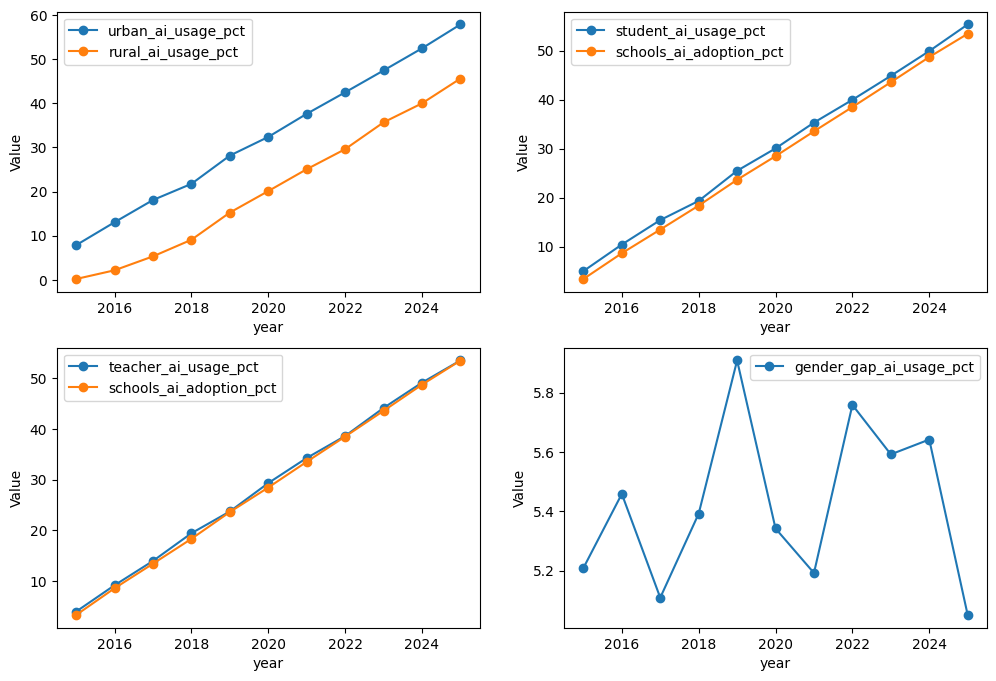

In [5]:
y_cols = [['urban_ai_usage_pct','rural_ai_usage_pct'],['student_ai_usage_pct','schools_ai_adoption_pct'], ['teacher_ai_usage_pct','schools_ai_adoption_pct'],['gender_gap_ai_usage_pct']]

fig, axs = viz.create_figure_grid(2, 2, figsize=(12,8))
axs = axs.flatten()

for i, col in enumerate(y_cols):
    viz.plot_line(
        axs[i],
        plot_data,
        'year',
        col
    )

In [6]:
fig_path = f'{config['paths']['figures']}/Time Seriers Analysis of Usage Metrics'
viz.save_figure(fig, fig_path)

- Urban AI usage consistently exceeds rural usage across years, indicating a persistent access or infrastructure gap. The gap widens during the initial years before stabilizing, suggesting gradual improvement in rural accessibility over time.
- Student AI usage consistently exceeds school-level AI adoption while maintaining a relatively stable gap across years, suggesting parallel growth between institutional adoption and student usage. Teacher AI usage also exceeds school adoption, though the gap varies more across years, indicating less consistent alignment.
- Student AI usage consistently exceeds teacher AI usage across years, suggesting faster adoption among students relative to teachers. The varying gap between the two indicates changing adoption dynamics over time.
- Gender gap in AI usage remains within a relatively narrow range across years, with no clear temporal trend visible. This suggests that gender-based differences remain comparatively stable over time.

### How do countries compare in terms of internet penetration and education index?

In [7]:
plot_data_path = f'{config['paths']['interim_data']}/{config['files']['structural_summary_country']}'
plot_data = data.load_dataset(f'{plot_data_path}.csv')
plot_data['internet_penetration_pct'] = plot_data['internet_penetration_pct']/100
plot_data = plot_data.sort_values(by='internet_penetration_pct', ascending=False)

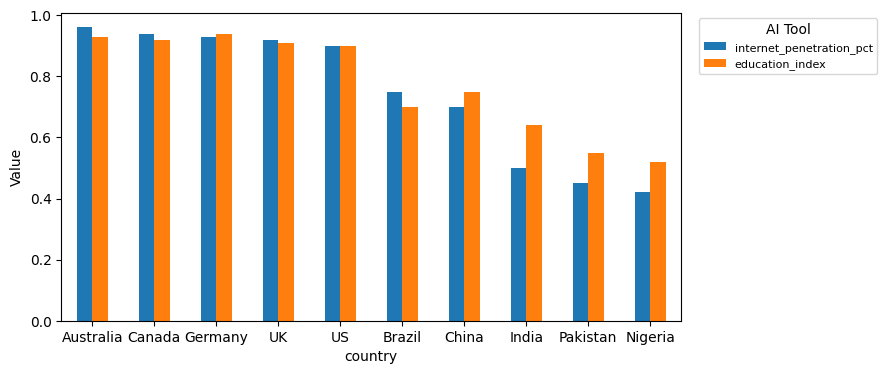

In [8]:
fig, axs = viz.create_figure_grid(1, 1, figsize=(8,4))

x_col = 'country'
y_col = ['internet_penetration_pct', 'education_index']

viz.plot_grouped_bar(axs, plot_data, x_col, y_col, rotation=0)

In [9]:
fig_path = f'{config['paths']['figures']}/Country Wise structural Comparison'
viz.save_figure(fig, fig_path)

- Countries with higher internet penetration generally also exhibit higher education index values, suggesting a positive association between digital infrastructure and educational development.
- Cross-country comparison shows that internet penetration tends to rise more sharply than education index at higher levels of development, while countries with lower internet penetration often maintain comparatively balanced education index values. Germany and Brazil deviate slightly from this broader pattern.

### How does internet penetration relate to AI usage patterns?

In [10]:
plot_data_path = f'{config['paths']['processed_data']}/{config['files']['processed_dataset']}'
plot_data = data.load_dataset(f'{plot_data_path}.csv')
plot_data['urban_rural_ai_usage_pct_gap'] = plot_data['urban_ai_usage_pct'] - plot_data['rural_ai_usage_pct']
plot_data = plot_data[['country', 'internet_penetration_pct', 'urban_rural_ai_usage_pct_gap', 'gender_gap_ai_usage_pct', 'avg_daily_ai_usage_min']]

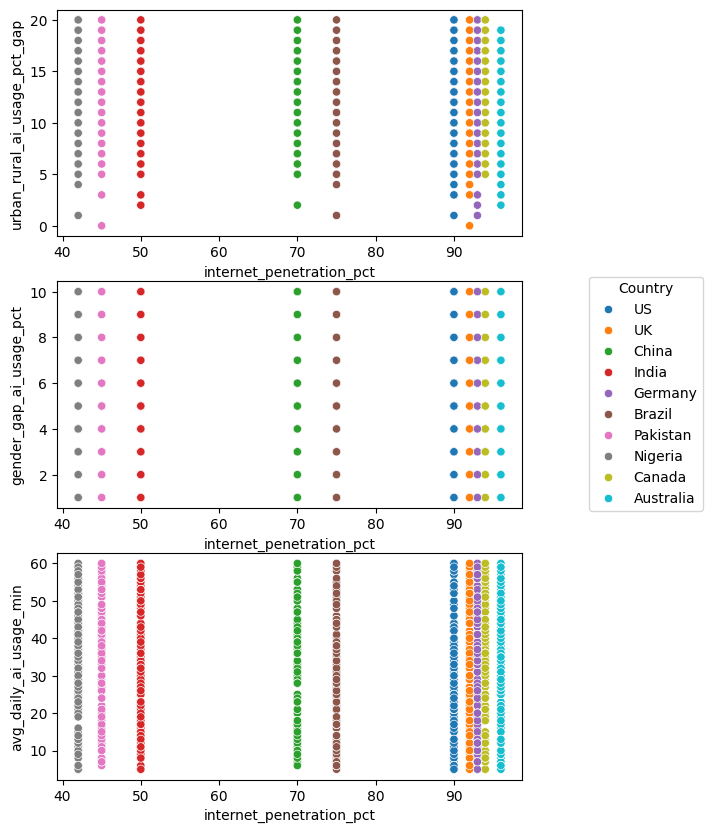

In [11]:
fig, axs = viz.create_figure_grid(3, 1, figsize=(6,10))

x_col = 'internet_penetration_pct'
y_cols = ['urban_rural_ai_usage_pct_gap', 'gender_gap_ai_usage_pct', 'avg_daily_ai_usage_min']

for i, col in enumerate(y_cols):
    viz.plot_scatter(axs[i], plot_data, x_col, col, hue='country', legend=(i == 0))

handles, labels = axs[0].get_legend_handles_labels()
axs[0].legend_.remove()

fig.legend(
    handles,
    labels,
    title='Country',
    bbox_to_anchor=(1, 0.62),
    loc='upper left'
)

In [12]:
fig_path = f'{config['paths']['figures']}/AI Usage by Internet Penetration'
viz.save_figure(fig, fig_path)

- Countries with higher internet penetration generally exhibit lower urban–rural AI usage gaps, suggesting improved accessibility of AI tools in rural areas with stronger digital infrastructure.
- Gender gap in AI usage remains relatively stable across countries with varying levels of internet penetration, indicating that internet accessibility alone may not strongly influence gender-based differences in AI usage.
- Average daily AI usage duration remains broadly similar across countries despite differences in internet penetration, suggesting that internet accessibility may have limited influence on overall daily usage duration.

### How does education index relate to AI adoption in educational systems?

In [13]:
plot_data_path = f'{config['paths']['processed_data']}/{config['files']['processed_dataset']}'
plot_data = data.load_dataset(f'{plot_data_path}.csv')
plot_data = plot_data[['country', 'education_index', 'student_ai_usage_pct', 'teacher_ai_usage_pct', 'schools_ai_adoption_pct']]

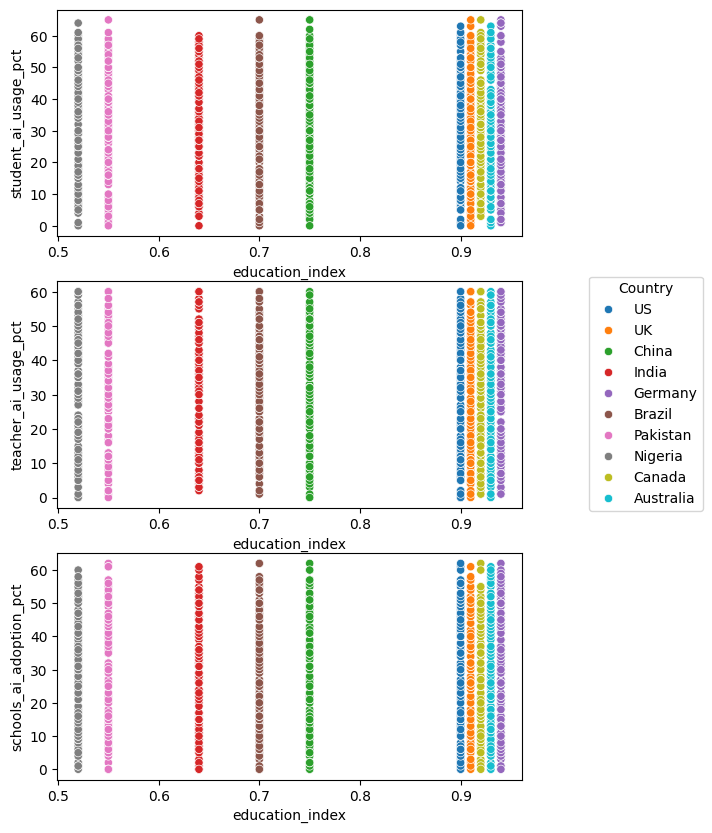

In [14]:
fig, axs = viz.create_figure_grid(3, 1, figsize=(6,10))

x_col = 'education_index'
y_cols = ['student_ai_usage_pct', 'teacher_ai_usage_pct', 'schools_ai_adoption_pct']

for i, col in enumerate(y_cols):
    viz.plot_scatter(axs[i], plot_data, x_col, col, hue='country', legend=(i == 0))

handles, labels = axs[0].get_legend_handles_labels()
axs[0].legend_.remove()

fig.legend(
    handles,
    labels,
    title='Country',
    bbox_to_anchor=(1, 0.62),
    loc='upper left'
)

In [15]:
fig_path = f'{config['paths']['figures']}/AI adoption by Education Index'
viz.save_figure(fig, fig_path)

- AI usage among students and teachers generally increases with higher education index levels, suggesting that stronger education systems are associated with greater adoption of emerging technologies.
- School-level AI adoption exhibits the strongest positive association with education index, indicating that institutional readiness may play a significant role in enabling AI integration.
- Countries with lower education index levels show greater variability in AI usage metrics, highlighting less consistent adoption and accessibility patterns.